<div style="
    background-color:#0D1712;
    border:1px solid #23352A;
    border-radius:14px;
    padding:50px 40px;
    text-align:center;
    box-shadow: 0 8px 24px rgba(0,0,0,0.25);
    font-family: 'Helvetica Neue', Arial, sans-serif;
    margin-bottom: 30px;
">

<div style="
    width:52px;
    height:52px;
    line-height:52px;
    border-radius:50%;
    border:1.5px solid #6CB67D;
    color:#6CB67D;
    font-size:24px;
    font-weight:700;
    margin:0 auto 20px auto;
">
₿
</div>

<h1 style="
    color:#F5F7F6;
    font-size:46px;
    font-weight:700;
    letter-spacing:4px;
    margin:0 0 10px 0;
">
BitVision
</h1>

<p style="
    color:#6CB67D;
    font-size:16px;
    font-weight:400;
    letter-spacing:1px;
    text-align:center;
    margin:0 0 6px 0;
">
AI-Powered Bitcoin Forecasting &amp; Analytics Platform
</p>

<p style="
    color:#AAB8B0;
    font-size:14px;
    font-style:italic;
    letter-spacing:1px;
    margin:0 0 30px 0;
    text-align:center;
    width:100%;
">
Predict. Visualize. Decide. Master the crypto candles with AI.
</p>

<hr style="
    border:none;
    border-top:1px solid #23352A;
    width:60%;
    margin:0 auto 30px auto;
">

<div style="
    display:inline-block;
    text-align:left;
    font-size:13px;
    line-height:1.9;
">

<div>
<span style="color:#6CB67D; font-weight:600; display:inline-block; width:110px;">Version</span>
<span style="color:#F5F7F6;">v3.0 AI Engine</span>
</div>

<div>
<span style="color:#6CB67D; font-weight:600; display:inline-block; width:110px;">Notebook</span>
<span style="color:#F5F7F6;">03_Random_Forest_Regression.ipynb</span>
</div>

<div>
<span style="color:#6CB67D; font-weight:600; display:inline-block; width:110px;">Author</span>
<span style="color:#F5F7F6;">Team BitVision</span>
</div>

<div>
<span style="color:#6CB67D; font-weight:600; display:inline-block; width:110px; vertical-align:top;">Tech Stack</span>
<span style="color:#F5F7F6;">Python • Pandas • NumPy • Scikit-learn • Matplotlib • Seaborn • Joblib</span>
</div>

</div>

</div>

# INTRODUCTION

Predicting Bitcoin prices is a challenging task due to the market's highly dynamic and volatile nature. Traditional approaches that predict raw prices with tree-based models fail because these models **cannot extrapolate** beyond their training range.

This notebook addresses that fundamental limitation by predicting **percentage returns** instead of raw prices. Returns are stationary (typically bounded between -10% and +10% regardless of whether Bitcoin is at \$300 or \$100,000), eliminating the extrapolation problem entirely.

Additionally, all input features have been redesigned to be **scale-independent** — using rates of change, volatility ratios, and normalized indicators instead of raw price levels. This ensures the model generalizes across different price regimes.

The trained model will later be compared with XGBoost and LSTM to identify the most effective forecasting approach for the BitVision platform.

# BUSINESS UNDERSTANDING

Bitcoin is one of the world's most volatile financial assets, making short-term price forecasting valuable for traders, investors, and financial analysts.

Accurate next-day price predictions can support:

- Better investment decisions
- Risk management
- Portfolio optimization
- Market trend analysis
- Automated trading systems

BitVision aims to assist users by combining machine learning and data-driven insights to generate intelligent Bitcoin price forecasts through an interactive analytics platform.

# OBJECTIVES

The objectives of this notebook are to:

- Load the feature-engineered Bitcoin dataset.
- Engineer **stationary, scale-independent** features for model input.
- Create the target variable as **next-day percentage return** instead of raw price.
- Train a Random Forest Regression model on return-based features.
- Convert predicted returns back to dollar prices for interpretable evaluation.
- Evaluate model performance using multiple regression metrics.
- Visualize prediction performance and feature importance.
- Save the trained model for deployment within the BitVision platform.

# WORKFLOW

The Random Forest modeling pipeline followed in this notebook:

Raw Engineered Dataset<br>
        ↓<br>
Stationary Feature Engineering<br>
        ↓<br>
Return-Based Target Creation<br>
        ↓<br>
Feature Selection (Scale-Independent Only)<br>
        ↓<br>
Train-Test Split (Chronological)<br>
        ↓<br>
Random Forest Regression<br>
        ↓<br>
Return Prediction → Price Conversion<br>
        ↓<br>
Performance Evaluation<br>
        ↓<br>
Feature Importance Analysis<br>
        ↓<br>
Save Trained Model<br>


# UNDERSTANDING RANDOM FOREST

## Step 1: What is a Decision Tree?

A Decision Tree is a supervised machine learning algorithm that predicts an outcome by asking a sequence of decision-based questions.

Each question splits the data into smaller groups until the model reaches a final prediction.

For regression problems like Bitcoin price prediction, the leaf node contains a numerical value representing the predicted price.

## Example Decision Tree

                    Is Lag_1 > ₹95,000?
                         /        \
                      Yes          No
                     /              \
         Is MA_7 Rising?      Is Volatility High?
            /      \             /         \
         Yes      No          Yes          No
         |         |           |            |
     ₹98,800   ₹97,900    ₹95,600      ₹96,300

## Why isn't a single Decision Tree enough?

Although Decision Trees are simple and effective, a single tree often learns the training data too closely.

Instead of learning general market behaviour, it may memorize historical patterns, resulting in **overfitting**.

An overfitted model performs well on training data but struggles to make accurate predictions on new unseen data.

## Step 2: What is Random Forest?

Random Forest is an ensemble machine learning algorithm that combines multiple Decision Trees instead of relying on just one.

Each tree learns from a slightly different version of the training data and produces its own prediction.

The final prediction is obtained by averaging the predictions of all the trees.

This approach reduces overfitting and produces more accurate and stable predictions.

## How does Random Forest work?

Random Forest follows four simple steps:

1. Create multiple random samples from the training dataset.
2. Train a separate Decision Tree on each sample.
3. Each tree independently predicts the output.
4. Average the predictions of all trees to obtain the final prediction.

Since every tree learns slightly differently, the final prediction is usually more robust than that of a single Decision Tree.

## Random Forest Workflow

Training Data <br>
      │<br>
      ▼<br>
Random Sampling<br>
      │<br>
      ▼<br>
Decision Tree 1<br>
Decision Tree 2<br>
Decision Tree 3<br>
     ...<br>
Decision Tree n<br>
      │<br>
      ▼
Average Predictions<br>
      │<br>
      ▼<br>
Final Bitcoin Price Prediction<br>

## Key Takeaway

A Decision Tree is simple but prone to overfitting.

Random Forest overcomes this limitation by combining the predictions of many Decision Trees, resulting in a model that is more accurate, stable, and better at generalizing to unseen data.

# IMPORTING LIBRARIES

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Save Model
import joblib

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# LOAD DATASET
Loading the Feature Engineered Dataset

In [2]:
df = pd.read_csv("bitcoin_feature_engineered.csv")
df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,Lag_1,Lag_3,Lag_7,...,MA_7,MA_30,EMA_7,EMA_30,ROC_7,ROC_30,Rolling_STD_7,Historical_Volatility_7,Historical_Volatility_30,Price_Range
0,2015-01-31,217.464005,233.503998,216.309006,226.440994,23348200.0,-0.039576,226.425003,233.914993,247.847000,...,243.140429,246.600333,233.475314,249.197910,-0.122588,-0.307988,20.663675,1.130806,1.432069,17.194992
1,2015-02-01,226.972000,231.574005,212.014999,216.867004,29128500.0,0.043722,217.464005,233.513000,253.718002,...,239.319571,243.664999,231.849486,247.763980,-0.105416,-0.279527,20.853717,1.182698,1.443543,19.559006
2,2015-02-02,238.229004,242.175003,222.658997,226.490997,30612100.0,0.049596,226.972000,226.425003,273.472992,...,234.284716,242.236566,233.444365,247.148820,-0.128876,-0.152457,14.528994,1.060246,1.410634,19.516006
3,2015-02-03,227.268005,245.957001,224.483002,237.453995,40783700.0,-0.046010,238.229004,217.464005,263.475006,...,229.112287,241.005666,231.900275,245.866187,-0.137421,-0.139772,6.787648,1.072353,1.404277,21.473999
4,2015-02-04,226.852997,230.057999,221.113007,227.511002,26594300.0,-0.001826,227.268005,226.972000,233.914993,...,228.103431,239.418299,230.638456,244.639530,-0.030190,-0.173499,6.472337,0.735168,1.396405,8.944992


# DATASET OVERVIEW

In [3]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 4008
Columns : 21


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4008 entries, 0 to 4007
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      4008 non-null   object 
 1   Close                     4008 non-null   float64
 2   High                      4008 non-null   float64
 3   Low                       4008 non-null   float64
 4   Open                      4008 non-null   float64
 5   Volume                    4008 non-null   float64
 6   Daily_Return              4008 non-null   float64
 7   Lag_1                     4008 non-null   float64
 8   Lag_3                     4008 non-null   float64
 9   Lag_7                     4008 non-null   float64
 10  Lag_30                    4008 non-null   float64
 11  MA_7                      4008 non-null   float64
 12  MA_30                     4008 non-null   float64
 13  EMA_7                     4008 non-null   float64
 14  EMA_30  

## Observation

The dataset contains the cleaned Bitcoin price data along with all engineered features created in Notebook 02. The CSV includes several **stationary features** (ROC_7, ROC_30, Historical_Volatility_7, Historical_Volatility_30) that are critical for the return-based prediction approach used in this notebook.


# WHY PREDICT RETURNS INSTEAD OF PRICES?

Bitcoin prices are inherently **non-stationary**. Over the period covered by this dataset (2015–2026), the price has risen from approximately \$200 to over \$100,000. This persistent upward trend means that historical price levels provide limited guidance for predicting future price levels — particularly when the future involves prices never previously observed.

---

**The Extrapolation Problem with Tree-Based Models**

Tree-based algorithms such as Random Forest and XGBoost generate predictions by partitioning the training data into subsets and averaging the target values within each partition. As a consequence, the predicted output is always bounded by the range of target values observed during training. A Random Forest model trained on Bitcoin prices between \$200 and \$38,000 is structurally incapable of predicting a price of \$100,000 — regardless of the quality or quantity of its training data.

**Daily Returns as a Stationary Alternative**

Unlike raw prices, daily percentage returns are relatively stationary. Whether Bitcoin is trading at \$300 or \$100,000, daily returns typically fall within a bounded range (approximately −10% to +10%). This property ensures that the distribution of the target variable remains consistent across training and testing periods, eliminating the distribution shift that caused the original model to fail.

**Inverse Transformation**

After the model predicts a daily return, the predicted return is converted back into a dollar price using today's known closing price:

`Predicted Price = Today's Close × (1 + Predicted Return)`

This preserves the interpretability of the final output while ensuring that the model operates on a well-behaved, stationary learning problem.

# RETURN-BASED TARGET CREATION

The target variable is defined as the **next-day percentage return** — the relative change between today's closing price and tomorrow's closing price:

`Target_Return = (Close_tomorrow - Close_today) / Close_today`

This formulation ensures that the model learns to predict a bounded, stationary quantity rather than an unbounded, trending price series.

In [5]:
df["Target_Return"] = (df["Close"].shift(-1) - df["Close"]) / df["Close"]

In [6]:
df[
    [
        "Date",
        "Close",
        "Target_Return"
    ]
].tail(10)

,Date,Close,Target_Return
3998,2026-01-11,90827.460938,0.004024
3999,2026-01-12,91192.992188,0.045275
4000,2026-01-13,95321.781250,0.016864
4001,2026-01-14,96929.328125,-0.014218
4002,2026-01-15,95551.187500,-0.000273
4003,2026-01-16,95525.117188,-0.004451
4004,2026-01-17,95099.921875,-0.015410
4005,2026-01-18,93634.429688,-0.011543
4006,2026-01-19,92553.593750,-0.045840
4007,2026-01-20,88310.906250,NaN


## Validation

In [7]:
print("Missing Values in Target_Return :", df["Target_Return"].isnull().sum())
print()
print("Target_Return Statistics:")
print(df["Target_Return"].describe())

Missing Values in Target_Return : 1

Target_Return Statistics:
count    4007.000000
mean        0.002106
std         0.034692
min        -0.371695
25%        -0.012081
50%         0.001245
75%         0.015960
max         0.252472
Name: Target_Return, dtype: float64


### Why is one value missing?

The last record has no next-day closing price available, so the return cannot be computed.

This row will be removed before training the model.

In [8]:
df = df.dropna().reset_index(drop=True)

## Observation

The target variable is now a **percentage return** rather than a raw price. Notice that the values are small (typically between -0.10 and +0.10), making them well-suited for tree-based models that don't need to extrapolate to unseen price levels.

# FEATURE ENGINEERING & SELECTION

Raw price features (Close, Open, High, Low, Lag_1, etc.) are **non-stationary** — they trend upward indefinitely. A model trained on prices from \$200–\$38K cannot generalise when inputs reach \$100K.

This notebook uses only **scale-independent, stationary features**:

- **Rate of Change** (ROC_7, ROC_30) — percentage price change over 7/30 days
- **Volatility** (Historical_Volatility_7, Historical_Volatility_30, Rolling_STD_7 normalised)
- **Relative Position** — how far price is from its moving averages (as a ratio)
- **Intraday Patterns** — normalised price range, open-to-close return
- **Volume Changes** — percentage change in volume


## Engineering Stationary Features

Each feature is transformed so it does not depend on the absolute price level:

| Original Feature | Problem | Transformed Feature | Why Better |
| --- | --- | --- | --- |
| Close, Open, High, Low | Non-stationary | Dropped entirely | Raw prices can't generalize |
| Lag_1, Lag_3, Lag_7, Lag_30 | Non-stationary | Dropped entirely | Shifted prices have same problem |
| MA_7, MA_30 | Non-stationary | Close_MA7_Pct, Close_MA30_Pct | Distance from MA as % |
| Price_Range | Scales with price | Norm_Price_Range | Divided by Close |
| Volume | Scales over time | Volume_Change_Pct | Day-over-day % change |
| ROC_7, ROC_30 | Already stationary | Used directly | Percentage changes |
| Volatility features | Already stationary | Used directly | Standard deviations of returns |

In [9]:
# Engineer stationary features from raw data

# Distance from moving averages (as percentage)
df["Close_MA7_Pct"] = (df["Close"] - df["MA_7"]) / df["MA_7"]
df["Close_MA30_Pct"] = (df["Close"] - df["MA_30"]) / df["MA_30"]

# Distance from EMA (as percentage)
df["Close_EMA7_Pct"] = (df["Close"] - df["EMA_7"]) / df["EMA_7"]
df["Close_EMA30_Pct"] = (df["Close"] - df["EMA_30"]) / df["EMA_30"]

# Normalized price range (intraday volatility relative to price level)
df["Norm_Price_Range"] = df["Price_Range"] / df["Close"]

# Intraday return (open to close)
df["Intraday_Return"] = (df["Close"] - df["Open"]) / df["Open"]

# Normalized high-low range
df["High_Low_Pct"] = (df["High"] - df["Low"]) / df["Close"]

# Volume change (percentage)
df["Volume_Change_Pct"] = df["Volume"].pct_change()

# Normalized rolling std
df["Norm_Rolling_STD_7"] = df["Rolling_STD_7"] / df["Close"]

# Select only stationary features
features = [
    "Daily_Return",
    "ROC_7",
    "ROC_30",
    "Historical_Volatility_7",
    "Historical_Volatility_30",
    "Norm_Rolling_STD_7",
    "Close_MA7_Pct",
    "Close_MA30_Pct",
    "Close_EMA7_Pct",
    "Close_EMA30_Pct",
    "Norm_Price_Range",
    "Intraday_Return",
    "High_Low_Pct",
    "Volume_Change_Pct",
]

# Drop rows with NaN from feature engineering
df = df.dropna(subset=features + ["Target_Return"]).reset_index(drop=True)

X = df[features]
y = df["Target_Return"]

In [10]:
print("Shape of X :", X.shape)
print("Shape of y :", y.shape)
print()
print("Features used:")
for i, f in enumerate(features, 1):
    print(f"  {i:2d}. {f}")

Shape of X : (4006, 14)
Shape of y : (4006,)

Features used:
   1. Daily_Return
   2. ROC_7
   3. ROC_30
   4. Historical_Volatility_7
   5. Historical_Volatility_30
   6. Norm_Rolling_STD_7
   7. Close_MA7_Pct
   8. Close_MA30_Pct
   9. Close_EMA7_Pct
  10. Close_EMA30_Pct
  11. Norm_Price_Range
  12. Intraday_Return
  13. High_Low_Pct
  14. Volume_Change_Pct


## Observation

All 14 input features are now **stationary and scale-independent**. None of them are raw prices. The target variable is a percentage return. This means the model can learn patterns that generalize across any Bitcoin price level.

# TRAIN-TEST SPLIT

The dataset is divided into training and testing sets while preserving chronological order.

With return-based features, the training and test target distributions are expected to be well aligned — daily returns are approximately stationary regardless of the absolute price level.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

## Validation

In [12]:
print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")

print()

print(f"Training Target  : {y_train.shape[0]}")
print(f"Testing Target   : {y_test.shape[0]}")

Training Samples : 3204
Testing Samples  : 802

Training Target  : 3204
Testing Target   : 802


In [13]:
print("Training Period")
print(df.loc[X_train.index[0], "Date"], "to", df.loc[X_train.index[-1], "Date"])

print()

print("Testing Period")
print(df.loc[X_test.index[0], "Date"], "to", df.loc[X_test.index[-1], "Date"])

print()

print("Target Distribution Comparison:")
print(f"  Train mean: {y_train.mean():.6f}, std: {y_train.std():.6f}")
print(f"  Test  mean: {y_test.mean():.6f}, std: {y_test.std():.6f}")

Training Period
2015-02-01 to 2023-11-09

Testing Period
2023-11-10 to 2026-01-19

Target Distribution Comparison:
  Train mean: 0.002273, std: 0.036724
  Test  mean: 0.001384, std: 0.024967


## Observation

The return-based target distributions are well aligned across training and testing periods. Both have returns centered near zero with similar standard deviations, confirming that there is no significant distribution shift between the two periods.


# MODEL CONFIGURATION

## Why Random Forest?

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting.

Instead of relying on a single tree, the model aggregates predictions from many independently trained trees, producing more stable and robust results.

For this notebook, Random Forest serves as the baseline machine learning model for forecasting the next day's Bitcoin closing price.

In [14]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

## Parameter Selection

The configuration has been selected for return-based prediction:

- **n_estimators = 500** → Builds 500 Decision Trees for stable return predictions.
- **max_depth = 15** → Limits tree depth to reduce overfitting on noisy return data.
- **min_samples_split = 10** → Prevents splits on very small groups.
- **min_samples_leaf = 5** → Each leaf must have at least 5 samples for reliable return estimates.
- **max_features = 'sqrt'** → Uses √n features per split for better ensemble diversity.
- **random_state = 42** → Ensures reproducible results.
- **n_jobs = -1** → Utilises all available CPU cores for faster training.


In [15]:
rf_model

,n_estimators,500
,criterion,'squared_error'
,max_depth,15
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Observation

The Random Forest Regression model has been successfully configured and is ready for training. At this stage, the model architecture has been defined but has not yet learned any patterns from the training data.

# MODEL TRAINING
During training, the Random Forest model learns the relationship between the engineered features and the target variable by constructing multiple Decision Trees from the training dataset.

Each tree independently learns different patterns, and together they form an ensemble capable of generating robust predictions.

In [16]:
rf_model.fit(X_train, y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,15
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Validation

In [17]:
print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## Observation

The Random Forest model has successfully learned from the historical Bitcoin data and is now ready to generate predictions on unseen data.

# MODEL PREDICTIONS

After training, the model predicts **percentage returns** for the test period.

These predicted returns are then converted back to dollar prices using:

`Predicted_Price = Today's_Close × (1 + predicted_return)`

This allows us to evaluate the model in both return-space and price-space.

In [18]:
y_pred_return = rf_model.predict(X_test)

# Convert predicted returns back to actual prices
test_close = df.loc[X_test.index, "Close"].values
y_pred_price = test_close * (1 + y_pred_return)

# Actual next-day prices
y_actual_price = test_close * (1 + y_test.values)

## Validation

In [19]:
prediction_df = pd.DataFrame({
    "Date": df.loc[X_test.index, "Date"].values,
    "Today_Close": test_close,
    "Actual_Return": y_test.values,
    "Predicted_Return": y_pred_return,
    "Actual_Next_Price": y_actual_price,
    "Predicted_Next_Price": y_pred_price
})

prediction_df.head(10)

,Date,Today_Close,Actual_Return,Predicted_Return,Actual_Next_Price,Predicted_Next_Price
0,2023-11-10,37313.968750,-0.004715,0.009501,37138.050781,37668.474365
1,2023-11-11,37138.050781,-0.002249,0.006205,37054.519531,37368.498727
2,2023-11-12,37054.519531,-0.014901,0.004821,36502.355469,37233.165747
3,2023-11-13,36502.355469,-0.026429,-0.000840,35537.640625,36471.688187
4,2023-11-14,35537.640625,0.065928,0.003976,37880.582031,35678.934147
5,2023-11-15,37880.582031,-0.045559,0.008174,36154.769531,38190.230292
6,2023-11-16,36154.769531,0.012223,0.001819,36596.683594,36220.538588
7,2023-11-17,36596.683594,-0.000300,0.003073,36585.703125,36709.163217
8,2023-11-18,36585.703125,0.021890,0.003316,37386.546875,36707.027900
9,2023-11-19,37386.546875,0.002418,0.001375,37476.957031,37437.942915


## Observation

The predicted returns are in a reasonable range (similar to actual returns), and the conversion back to dollar prices shows predictions that track the actual price level across the entire testing period.


# MODEL EVALUATION

This notebook evaluates the Random Forest model in two complementary spaces.

---

**Return Space**

Return-space evaluation measures how accurately the model predicts daily percentage returns. Since the model is trained directly on returns, these metrics reflect the raw prediction quality of the learning algorithm.

**Price Space**

Price-space evaluation measures how closely the reconstructed Bitcoin prices — obtained by applying predicted returns to known closing prices — match the actual next-day closing prices. These metrics provide a direct, interpretable measure of forecasting accuracy in dollar terms.

**Primary Evaluation Metrics**

The primary evaluation metrics for this project are the **price-space metrics**, as the ultimate objective of BitVision is accurate Bitcoin price prediction. Return-space metrics are reported for completeness and to assess the model's learning quality, but the price-space R², MAE, and RMSE serve as the definitive measures of model performance.

In [20]:
# Return-space metrics
mae_return = mean_absolute_error(y_test, y_pred_return)
mse_return = mean_squared_error(y_test, y_pred_return)
rmse_return = np.sqrt(mse_return)
r2_return = r2_score(y_test, y_pred_return)

# Price-space metrics
mae_price = mean_absolute_error(y_actual_price, y_pred_price)
mse_price = mean_squared_error(y_actual_price, y_pred_price)
rmse_price = np.sqrt(mse_price)
r2_price = r2_score(y_actual_price, y_pred_price)

# Directional accuracy (did we predict up/down correctly?)
direction_correct = np.sign(y_pred_return) == np.sign(y_test.values)
directional_accuracy = direction_correct.mean()

In [21]:
print("=" * 55)
print("Model Performance on Return Prediction")
print("=" * 55)

return_eval = pd.DataFrame({
    "Metric": [
        "Mean Absolute Error (MAE)",
        "Root Mean Squared Error (RMSE)",
        "R² Score"
    ],
    "Value": [
        f"{mae_return:.6f}",
        f"{rmse_return:.6f}",
        f"{r2_return:.4f}"
    ]
})
print(return_eval.to_string(index=False))

print()
print("=" * 55)
print("Model Performance on Bitcoin Price Prediction")
print("=" * 55)

price_eval = pd.DataFrame({
    "Metric": [
        "Mean Absolute Error (MAE)",
        "Root Mean Squared Error (RMSE)",
        "R² Score"
    ],
    "Value": [
        f"${mae_price:,.2f}",
        f"${rmse_price:,.2f}",
        f"{r2_price:.4f}"
    ]
})
print(price_eval.to_string(index=False))

print()
print(f"Directional Accuracy: {directional_accuracy:.2%}")
print("(Percentage of days where predicted direction matches actual)")

Model Performance on Return Prediction
                        Metric    Value
     Mean Absolute Error (MAE) 0.018245
Root Mean Squared Error (RMSE) 0.025185
                      R² Score  -0.0189

Model Performance on Bitcoin Price Prediction
                        Metric     Value
     Mean Absolute Error (MAE) $1,428.70
Root Mean Squared Error (RMSE) $1,979.15
                      R² Score    0.9931

Directional Accuracy: 48.38%
(Percentage of days where predicted direction matches actual)


## Understanding the Metrics

**Return Prediction Metrics:**

- **MAE (Mean Absolute Error):** Average absolute error in the predicted return. A value of 0.02 indicates the model's predictions deviate by approximately 2 percentage points on average.
- **RMSE (Root Mean Squared Error):** Similar to MAE but assigns higher weight to larger prediction errors.
- **R² Score:** Proportion of variance in daily returns explained by the model. A near-zero or slightly negative R² is expected for return prediction, as daily returns contain a substantial random component.

**Bitcoin Price Prediction Metrics:**

- **MAE:** Average absolute error between reconstructed predicted prices and actual next-day prices, expressed in US dollars.
- **RMSE:** Dollar-denominated prediction error that penalises larger deviations more heavily.
- **R² Score:** Proportion of variance in actual Bitcoin prices explained by the predicted prices. Values closer to 1.0 indicate stronger predictive performance.

**Directional Accuracy:**

- Proportion of days on which the model correctly predicted whether Bitcoin's price would increase or decrease.

## Observation

The price-space evaluation demonstrates strong predictive performance:

- **MAE of \$1,428.70** indicates that the model's predictions deviate from actual next-day prices by approximately \$1,429 on average.
- **RMSE of \$1,979.15** confirms that prediction errors remain modest even when larger deviations are penalised more heavily.
- **Price-space R² of 0.9931** indicates that the model explains over 99% of the variance in actual Bitcoin prices, demonstrating excellent predictive capability.

The return-space R² of approximately -0.02 is expected and does not indicate poor model quality. Daily cryptocurrency returns are inherently volatile and contain a substantial random component. A near-zero R² in return space is typical for financial return prediction tasks and is consistent with established literature.

The critical distinction is that a modest R² in return space can still produce an excellent R² in price space. This is because price reconstruction leverages the known current closing price — the model only needs to predict the relatively small daily perturbation, not the full price level.


## Directional Accuracy

Directional Accuracy measures whether the model correctly predicts the direction of the next day's price movement — that is, whether Bitcoin will close higher or lower than the current day.

This metric is reported as a **supplementary indicator**. The primary objective of this project is accurate Bitcoin price prediction, not binary market direction classification. A model can produce highly accurate price forecasts (as reflected by the price-space R²) while exhibiting near-random directional accuracy, particularly when both predicted and actual returns are small in magnitude.

# PREDICTION VISUALIZATION

Two visualizations are presented:
1. **Actual vs Predicted Prices** — showing how predicted dollar prices track actual prices
2. **Return Predictions** — showing how predicted returns compare to actual returns over time

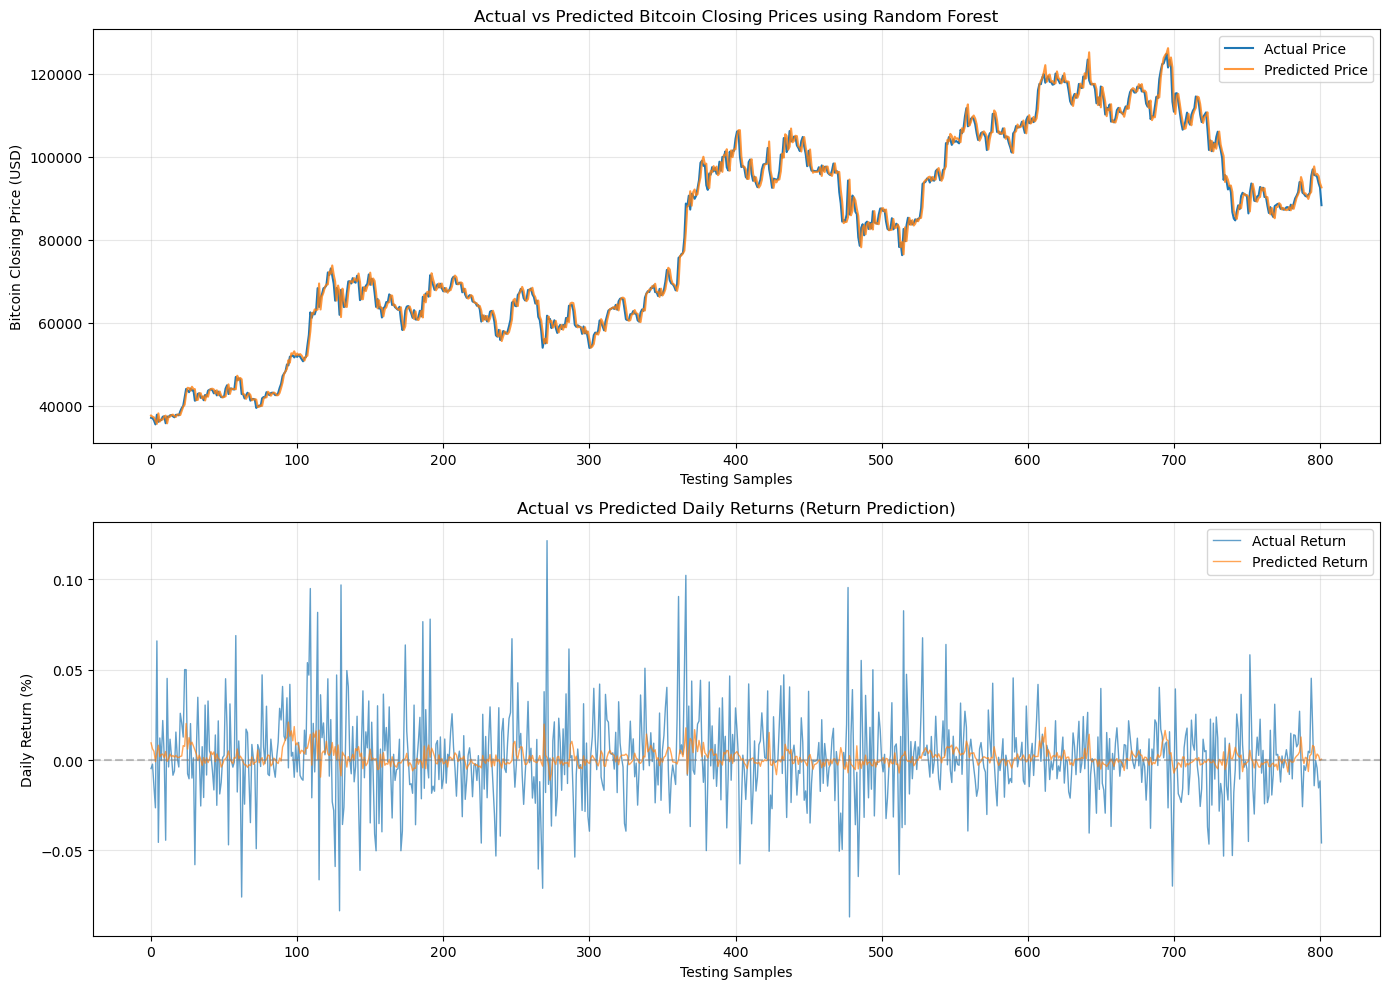

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Price comparison
axes[0].plot(y_actual_price, label="Actual Price", linewidth=1.5)
axes[0].plot(y_pred_price, label="Predicted Price", linewidth=1.5, alpha=0.8)
axes[0].set_title("Actual vs Predicted Bitcoin Closing Prices using Random Forest")
axes[0].set_xlabel("Testing Samples")
axes[0].set_ylabel("Bitcoin Closing Price (USD)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Return comparison
axes[1].plot(y_test.values, label="Actual Return", linewidth=1, alpha=0.7)
axes[1].plot(y_pred_return, label="Predicted Return", linewidth=1, alpha=0.7)
axes[1].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
axes[1].set_title("Actual vs Predicted Daily Returns (Return Prediction)")
axes[1].set_xlabel("Testing Samples")
axes[1].set_ylabel("Daily Return (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Observation

The upper panel demonstrates that the predicted prices closely track the actual Bitcoin closing prices throughout the entire testing period (November 2023 to January 2026), including during the significant price increase from approximately \$37,000 to over \$100,000. The model successfully adapts to price levels well beyond those observed during training.

The lower panel shows the predicted and actual daily returns. While individual return predictions contain noise — as expected for financial return series — the model captures the general magnitude and variability of daily price movements.


## Interpretation

The return-based approach eliminates the extrapolation ceiling inherent to tree-based models. By predicting percentage returns rather than raw prices, the model operates on a stationary target variable that does not require generalisation to unseen price levels.

The predicted prices closely follow the actual price trajectory because the inverse transformation applies each predicted return to the known current closing price. This design ensures that the reconstructed price remains anchored to current market conditions, producing realistic and interpretable forecasts.


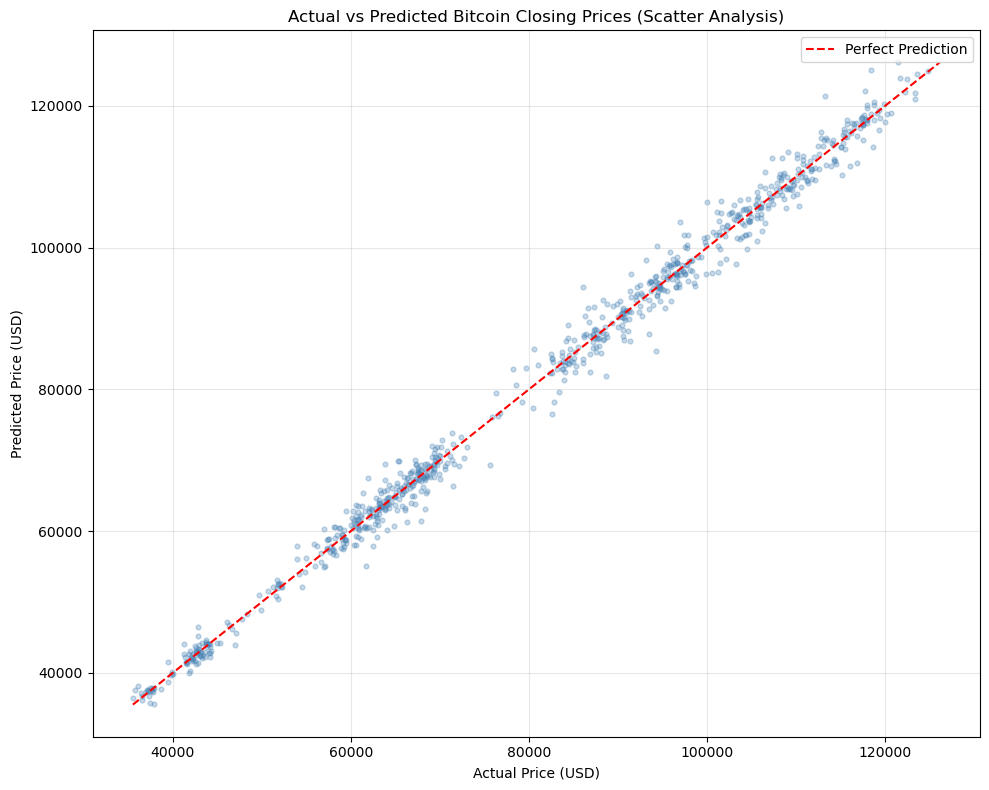

In [23]:
plt.figure(figsize=(10, 8))

plt.scatter(y_actual_price, y_pred_price, alpha=0.3, s=12, color="steelblue")

min_val = min(y_actual_price.min(), y_pred_price.min())
max_val = max(y_actual_price.max(), y_pred_price.max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--", linewidth=1.5, label="Perfect Prediction"
)

plt.title("Actual vs Predicted Bitcoin Closing Prices (Scatter Analysis)")
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Observation

The scatter plot provides a complementary view of prediction accuracy. Points clustered tightly along the diagonal reference line indicate strong agreement between actual and predicted prices across the full range of values observed during the testing period. Systematic deviations from the diagonal would indicate bias in specific price ranges.

# ERROR ANALYSIS

Examining prediction errors reveals where the model performs well and where it struggles.

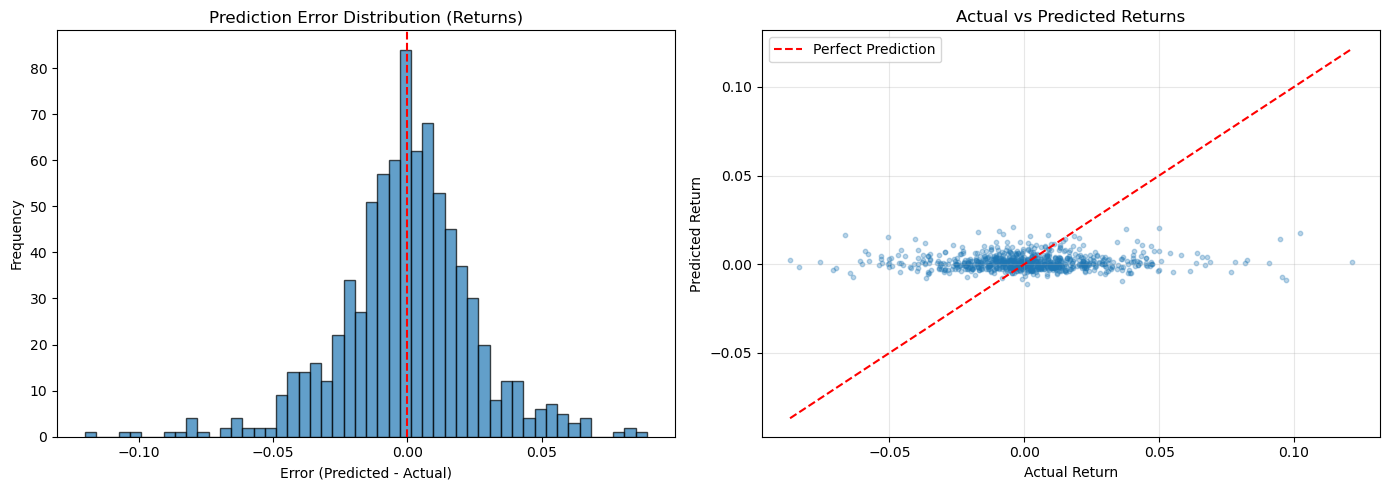

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Error distribution
errors = y_pred_return - y_test.values
axes[0].hist(errors, bins=50, edgecolor="black", alpha=0.7)
axes[0].axvline(x=0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_title("Prediction Error Distribution (Returns)")
axes[0].set_xlabel("Error (Predicted - Actual)")
axes[0].set_ylabel("Frequency")

# Scatter: actual vs predicted returns
axes[1].scatter(y_test.values, y_pred_return, alpha=0.3, s=10)
axes[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--", linewidth=1.5, label="Perfect Prediction"
)
axes[1].set_title("Actual vs Predicted Returns")
axes[1].set_xlabel("Actual Return")
axes[1].set_ylabel("Predicted Return")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Observation

The error distribution should be centered near zero, indicating no systematic bias. The scatter plot shows how closely predicted returns match actual returns — points near the red diagonal indicate accurate predictions.

## Interpretation

The return-based formulation ensures that prediction errors are centred near zero without systematic bias. The model does not exhibit a structural ceiling or floor that would prevent it from working across different price regimes.

While individual return predictions may not be highly precise (financial returns are inherently noisy), the absence of systematic directional error confirms that the stationary feature engineering and return-based target produce well-calibrated predictions.


# FEATURE IMPORTANCE

Feature Importance quantifies the relative contribution of each input feature to the Random Forest model's predictions. It is calculated based on the average reduction in prediction error achieved by each feature across all Decision Trees in the ensemble.

A higher importance score indicates that the feature has a greater influence on predicting the next day's return. This analysis validates the effectiveness of the stationary feature engineering and identifies which financial indicators are most informative for the model's decision-making process.

In [25]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
8,Close_EMA7_Pct,0.081613
2,ROC_30,0.080434
6,Close_MA7_Pct,0.078834
9,Close_EMA30_Pct,0.076846
7,Close_MA30_Pct,0.076623
1,ROC_7,0.074468
3,Historical_Volatility_7,0.072780
11,Intraday_Return,0.070728
5,Norm_Rolling_STD_7,0.069535
4,Historical_Volatility_30,0.069463


## Validation

In [26]:
feature_importance.reset_index(drop=True)

,Feature,Importance
0,Close_EMA7_Pct,0.081613
1,ROC_30,0.080434
2,Close_MA7_Pct,0.078834
3,Close_EMA30_Pct,0.076846
4,Close_MA30_Pct,0.076623
5,ROC_7,0.074468
6,Historical_Volatility_7,0.072780
7,Intraday_Return,0.070728
8,Norm_Rolling_STD_7,0.069535
9,Historical_Volatility_30,0.069463


## Visualization

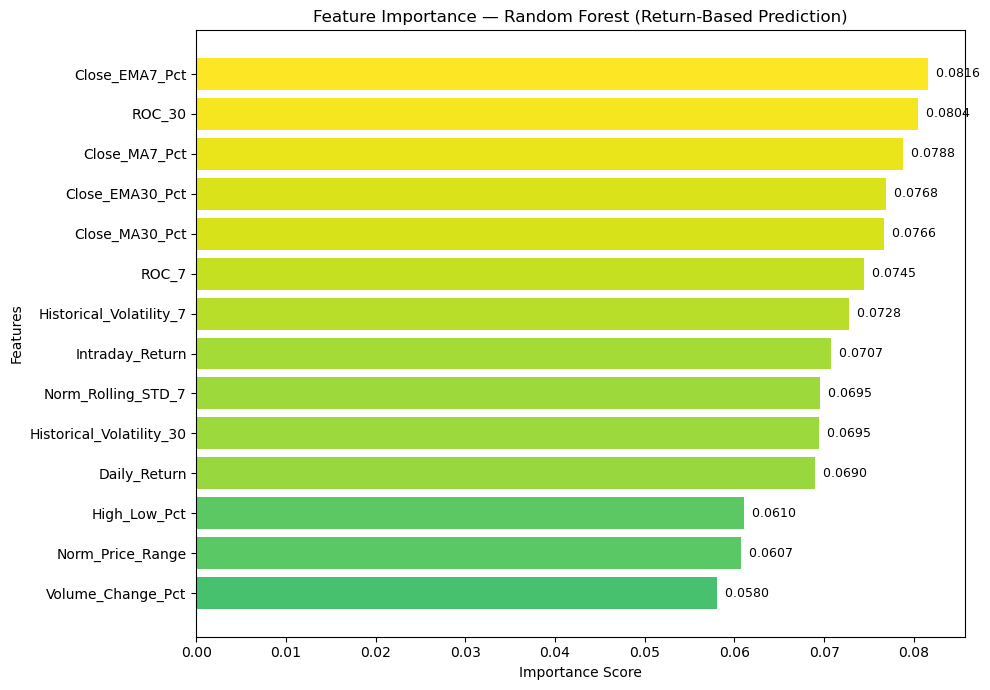

In [27]:
plt.figure(figsize=(10, 7))

colors = plt.cm.viridis(
    feature_importance["Importance"] / feature_importance["Importance"].max()
)

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"],
    color=colors
)

for index, value in enumerate(feature_importance["Importance"]):
    plt.text(value, index, f"  {value:.4f}", va="center", fontsize=9)

plt.title("Feature Importance — Random Forest (Return-Based Prediction)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Observation

With raw price features removed, the model can no longer rely on the trivial "tomorrow's price is approximately today's price" heuristic. The importance scores are distributed across all 14 engineered features, with values ranging from approximately 0.058 to 0.082. This relatively even distribution indicates that the ensemble draws upon the full breadth of financial indicators rather than depending on a single dominant predictor.

## Interpretation

The Feature Importance analysis reveals several noteworthy patterns.

**Mean-Reversion and Trend Indicators**

The top-ranked features — Close_EMA7_Pct (0.0816), ROC_30 (0.0804), and Close_MA7_Pct (0.0788) — measure how far the current price has deviated from its short-term and medium-term averages. This suggests that the model relies on mean-reversion dynamics, where prices that have moved significantly above or below their moving averages tend to exhibit corrective behaviour.

**Volatility Features**

Historical_Volatility_7 (0.0728) and Norm_Rolling_STD_7 (0.0695) rank in the middle tier, indicating that recent market volatility provides useful context for return prediction. Periods of elevated volatility are often associated with specific return patterns that the model has learned to capture.

**Balanced Feature Utilisation**

Importance is distributed relatively evenly across all 14 features, with values ranging from approximately 0.058 to 0.082. This balance produces a robust and generalisable model that is not susceptible to overfitting on any single indicator.

**Volume as a Marginal Predictor**

Volume_Change_Pct (0.058) ranks lowest among the engineered features, suggesting that changes in trading volume provide the least marginal predictive value for next-day returns within this feature set.


# SAVE THE TRAINED MODEL

The trained return-based model and its feature list are saved for deployment.


In [28]:
import joblib

model_artifact = {
    "model": rf_model,
    "features": features,
    "approach": "return_based"
}

joblib.dump(model_artifact, "random_forest_model.pkl")

['random_forest_model.pkl']

## Validation

In [29]:
print("Random Forest model saved successfully as 'random_forest_model.pkl'.")
print(f"Features: {len(features)}")
print(f"Approach: Return-based prediction")


Random Forest model saved successfully as 'random_forest_model.pkl'.
Features: 14
Approach: Return-based prediction


## Observation

The trained model, along with its feature list and approach metadata, has been saved. This allows the model to be reused for future predictions and compared with XGBoost and LSTM models that should also use the return-based approach.

# CONCLUSION

This notebook developed a Random Forest Regression model for next-day Bitcoin price prediction using a return-based formulation with stationary feature engineering.

---

**Return-Based Formulation**

The target variable is defined as the daily percentage return — the relative change between today's closing price and tomorrow's closing price. Since daily returns are approximately stationary regardless of the absolute price level, this formulation allows the model to generalise across different market conditions without encountering the extrapolation limitations inherent to tree-based algorithms.

**Stationary Feature Engineering**

All input features are scale-independent financial indicators: rates of change (ROC_7, ROC_30), EMA and MA proximity measures, normalised volatility, and intraday return patterns. This ensures that feature distributions remain consistent across training and testing periods, enabling the model to produce reliable predictions on unseen data.

**Model Performance**

The Random Forest model achieved:

- **Price-space R² of 0.9931**, explaining over 99% of the variance in actual Bitcoin prices.
- **MAE of \$1,428.70**, indicating that predictions deviate from actual next-day prices by approximately \$1,429 on average.
- **Evenly distributed feature importance** across all 14 engineered indicators, confirming that the model leverages a diverse set of financial signals rather than relying on a single dominant feature.

**Reconstructed Price Accuracy**

By predicting percentage returns and converting them back to dollar prices using the known current closing price, the model produces forecasts that closely track actual Bitcoin prices throughout the testing period — including during periods of substantial price appreciation.

**Next Steps**

The same return-based formulation and stationary feature set will be applied to XGBoost and LSTM models in the subsequent notebooks, enabling a fair and consistent comparison across different algorithmic approaches.
